# EDA and SQL Analysis:- Telco Customer Churn

This notebook focuses on analyzing the Telco Customer Churn dataset to understand customer behavior, churn patterns, and potential business insights.

The dataset is first loaded and explored, followed by the calculation of key performance indicators (KPIs) to provide an overall view of the customer base and churn.

The analysis then uses SQL to answer business-focused questions and identify patterns related to customer churn.

The main objectives of this notebook are:

- Calculate key performance indicators related to customers, churn, and revenue
- Analyze customer churn across different customer segments
- Identify factors associated with a higher risk of churn
- Answer business-focused questions using SQL
- Generate insights that can support customer retention and revenue protection

The analysis aims to better understand **who is churning, why they may be churning, and where the business faces the greatest customer and revenue risk.**

## 1. SETTING UP THE DATASET
##### Imported libraries like NumPy, Pandas, MathplotLib, Seaborn, Os and Pathlib and loaded the dataset 
- The data set have 7043 rows  and 21 columns


In [24]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
from sqlalchemy import create_engine,URL

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME
)

engine = create_engine(database_url)


conn = psycopg2.connect(
    host="localhost",
    database=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)

file_path = Path("..") / "Data" / "Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Key Performance Indicators (KPIs)

Before analyzing individual customer segments, key performance indicators are calculated to provide an overall view of the customer base, churn, and revenue.

The KPIs include:

- **Total Customers:** The total number of customers in the dataset.
- **Churned Customers:** The number of customers who have discontinued the service.
- **Retained Customers:** The number of customers who have continued using the service.
- **Churn Rate:** The percentage of customers who have churned.
- **Retaintion Rate:** The percentage of customers who have retained.
- **Monthly Revenue:** The total monthly revenue generated from all customers.
- **Monthly Revenue LOSS:** The monthly revenue associated with customers who have churned.
- **Monthly Revenue Risk Share:** The percentage of total monthly revenue represented by churned customers.
- **Average Revenue Per user:** The average revenue genrated by each user.
- **Average Tenure:** Average tenure of customers(in months)


These KPIs provide a high-level understanding of the scale of customer churn and its potential impact on monthly revenue.

In [25]:
total_customers = len(df)
churned_customers = len(df[df["Churn"] == "Yes"])
retained_customers = total_customers - churned_customers
churn_rate = (churned_customers/total_customers)*100
retention_rate = 100 - churn_rate

total_monthly_revenue = df["MonthlyCharges"].sum()
total_monthly_revenue_loss = df.loc[df["Churn"] == "Yes","MonthlyCharges"].sum()
average_revenue_per_customer = df["MonthlyCharges"].mean()

average_tenure = df["tenure"].mean()
average_churned_tenure = df.loc[df["Churn"] == "Yes","tenure"].mean()

In [26]:
kpi_data = {
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate",
        "Retention Rate",
        "Total Monthly Revenue",
        "Total Monthly Revenue Loss",
        "Average Revenue Per User",
        "Average Tenure"
    ],

    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        f"{churn_rate:.2f}%",
        f"{retention_rate:.2f}%",
        f"${total_monthly_revenue:,.2f}",
        f"${total_monthly_revenue_loss:,.2f}",
        f"${average_revenue_per_customer:,.2f}",
        f"{average_tenure:.2f} months"
    ]
}

kpi_df = pd.DataFrame(kpi_data)

kpi_df

,KPI,Value
0,Total Customers,7043
1,Churned Customers,1869
2,Retained Customers,5174
3,Churn Rate,26.54%
4,Retention Rate,73.46%
5,Total Monthly Revenue,"$456,116.60"
6,Total Monthly Revenue Loss,"$139,130.85"
7,Average Revenue Per User,$64.76
8,Average Tenure,32.37 months


## 3. SQL Business Analysis

SQL is used to answer business-focused questions and identify patterns related to customer churn, customer behavior, and revenue.

The analysis explores how churn varies across different customer segments and identifies factors that may be associated with a higher risk of customer churn.

The SQL analysis focuses on questions related to:

### 1. Effect Of Contract types on Churn Rate

,contract,total_customers,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Month-to-month,3875,1655,42.7%,257294.15,120847.10
1,One year,1472,166,11.3%,95796.90,14118.45
2,Two year,1685,48,2.8%,102569.95,4165.30


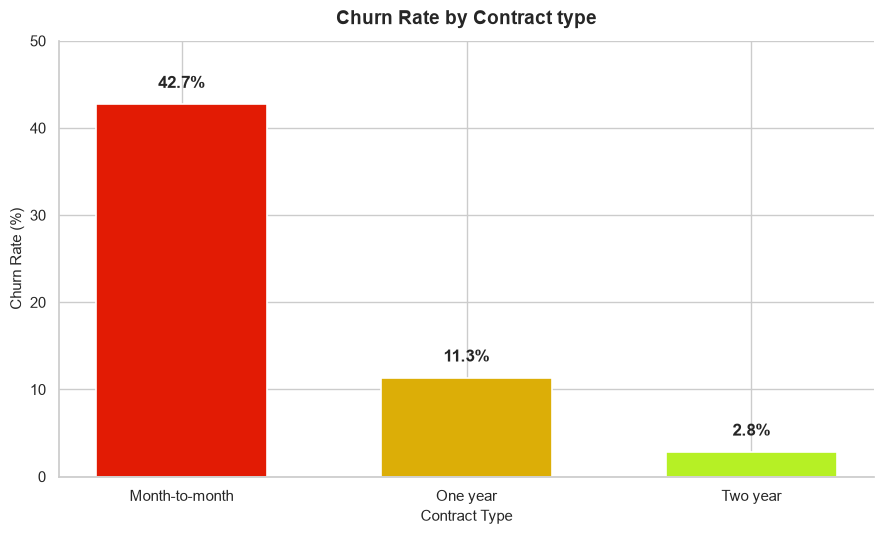

In [27]:
sql_file_path = Path("..") / "Queries" / "01_churn_rate_by_contract_type.sql"

with open(sql_file_path) as f:
    query = f.read()
contract_churn = pd.read_sql(query, engine)


display_result = contract_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = contract_churn["contract"]
rates = contract_churn["churn_rate"]

colors = ["#e21b04", "#dcae07", "#b6f025"]

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate by Contract type", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Contract Type", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 50)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by Contract Type")
plt.show()


**Conclusion:** Customers with `Month-to-Month` contract type have higher chrn rate as compared to other type

### 2. Effect of tenure period on Churn Rate

,tenure_bucket,total_customers,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,0-12 months,2175,1037,47.7%,122174.15,68954.25
1,13-24 months,1024,294,28.7%,62829.85,23081.65
2,25-48 months,1594,325,20.4%,105093.30,27462.50
3,48-60 months,832,120,14.4%,58698.25,10581.90
4,60-72 months,1407,93,6.6%,106865.45,9050.55


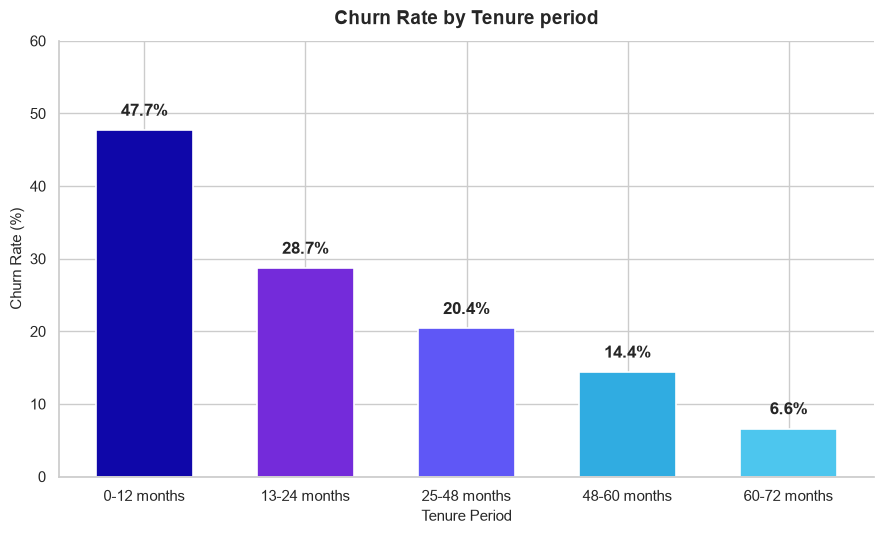

In [28]:
sql_file_path = Path("..") / "Queries" / "02_churn_rate_by_tenure_period.sql"

with open(sql_file_path) as f:
    query = f.read()
tenure_churn = pd.read_sql(query, engine)

display_result = tenure_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = tenure_churn["tenure_bucket"]
rates = tenure_churn["churn_rate"]

colors = ["#0f07a9", "#742bda", "#5f57f6", "#30ace1", "#4dc6ee"]

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate by Tenure period", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Tenure Period", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 60)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by Tenure period")
plt.show()

**Conclusion:** The customers with tenure between 0-12 months tends to churn more as compare to others, which also reflects the churn being higher for month-to-month contract

### 3. Churn Rate By Services Provided 

,service,customer_count,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Streaming Movies,2731,818,30.0%,455661.0,139130.85
1,Streaming TV,2703,814,30.0%,455661.0,139130.85
2,Device Protection,2418,545,23.0%,455661.0,139130.85
3,Online Backup,2425,523,22.0%,455661.0,139130.85
4,Tech Support,2040,310,15.0%,455661.0,139130.85
5,Online Security,2015,295,15.0%,455661.0,139130.85


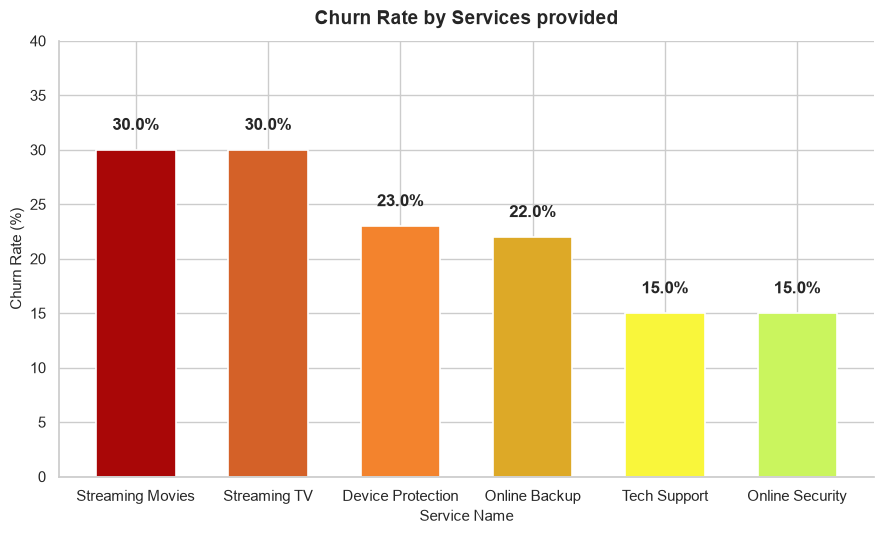

In [29]:
sql_file_path = Path("..") / "Queries" / "03_churn_rate_by_Services_provided.sql"

with open(sql_file_path) as f:
    query = f.read()
services_churn = pd.read_sql(query, engine)

display_result = services_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = services_churn["service"]
rates = services_churn["churn_rate"]

colors = ["#a90707", "#d46128", "#f3832d", "#dda927", "#f9f63b", "#caf55e"]

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate by Services provided", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Service Name", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 40)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by Services Provided")
plt.show()

**Conclusion:** The customers tend to churn more on straming services, while the churn rate of services like tech support and online security in half of them

### 4. Effect of Internet Type on Churn Rate

,internet_service,no_of_customers,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Fiber optic,3096,1297,42.0%,283284.40,114300.05
1,DSL,2416,459,19.0%,140340.65,22529.20
2,No,1520,113,7.0%,32035.95,2301.60


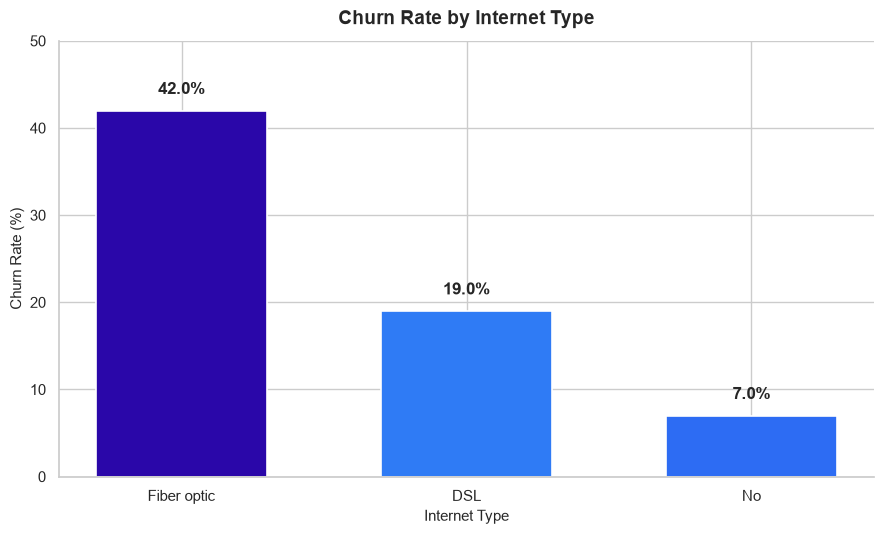

In [30]:
sql_file_path = Path("..") / "Queries" / "04_churn_rate_by_internet_type.sql"

with open(sql_file_path) as f:
    query = f.read()
internet_churn = pd.read_sql(query, engine)

display_result = internet_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = internet_churn["internet_service"]
rates = internet_churn["churn_rate"]

colors = ["#2a07a9", "#2f7bf5", "#2d6cf3"]

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate by Internet Type", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Internet Type", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 50)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by Internet type")
plt.show()


**Conclusion:** The customers having fiber optic Internet type churn 6X more than the customers with no internet

### 5. Effect of payment method on Churn Rate

,payment_method,no_of_customers,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Electronic check,2365,1071,45.29%,180345.0,84288.75
1,Mailed check,1604,308,19.2%,70509.2,16803.60
2,Bank transfer (automatic),1542,258,16.73%,103631.0,20091.90
3,Credit card (automatic),1521,232,15.25%,101175.8,17946.60


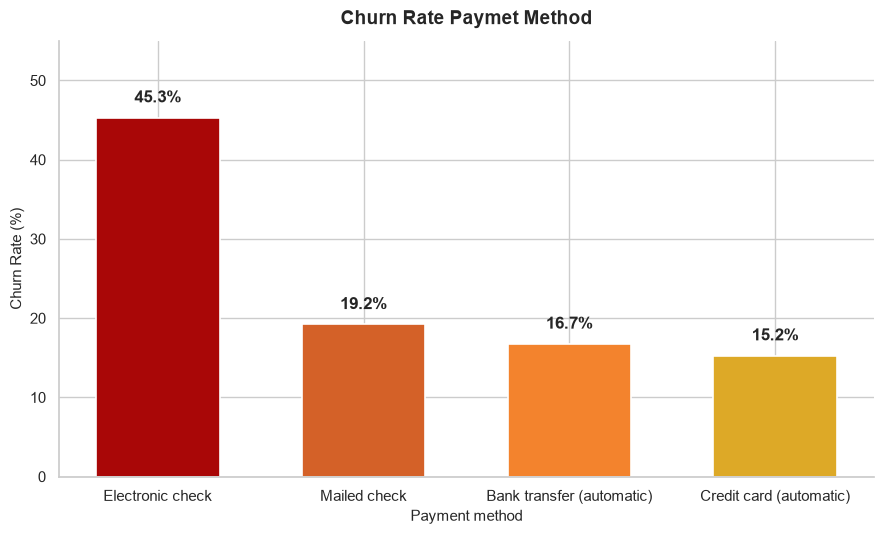

In [31]:
sql_file_path = Path("..") / "Queries" / "05_churn_rate_by_payment_method.sql"

with open(sql_file_path) as f:
    query = f.read()
payment_churn = pd.read_sql(query, engine)

display_result = payment_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = payment_churn["payment_method"]
rates = payment_churn["churn_rate"]

colors = ["#a90707", "#d46128", "#f3832d", "#dda927"]

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate Paymet Method", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Payment method", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 55)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by Payment Method")
plt.show()



**Conclusion:** The custmors who pays with electronic check churn significanly more than other customers

### 6. Effects of Charge Category on Churn rate

,charge_category,total_customers,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Regular Charges,614,381,62.1%,31042.25,22209.45
1,Discounted,3214,750,23.3%,211749.60,57774.75
2,Additional Charges,3204,738,23.0%,212869.15,59146.65


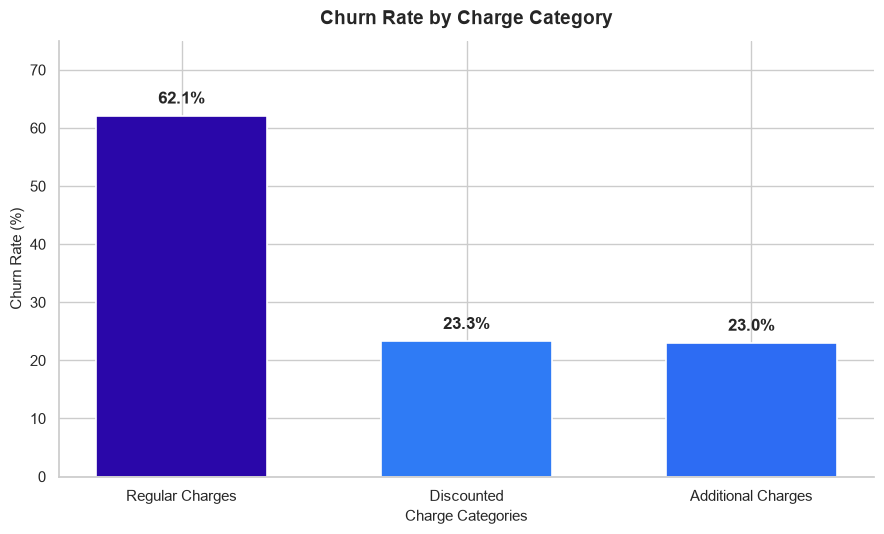

In [32]:
sql_file_path = Path("..") / "Queries" / "06_churn_rate_by_charge_category.sql"

with open(sql_file_path) as f:
    query = f.read()
charge_category_churn = pd.read_sql(query, engine)

display_result = charge_category_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = charge_category_churn["charge_category"]
rates = charge_category_churn["churn_rate"]

colors = ["#2a07a9", "#2f7bf5", "#2d6cf3"] 

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate by Charge Category", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Charge Categories", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 75)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by Charge Category")
plt.show()

**Conclusion:** The customer who i have recieved discounts/additional charges have approximatly 3 times lower churn rate than the customers who have recevied nothing 

### 7. Effect of Partner/Dependents on Churn Rate

,household_status,customer_count,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Partner,3393,669,20.0%,455661.0,139130.85
1,Dependents,2099,326,16.0%,455661.0,139130.85


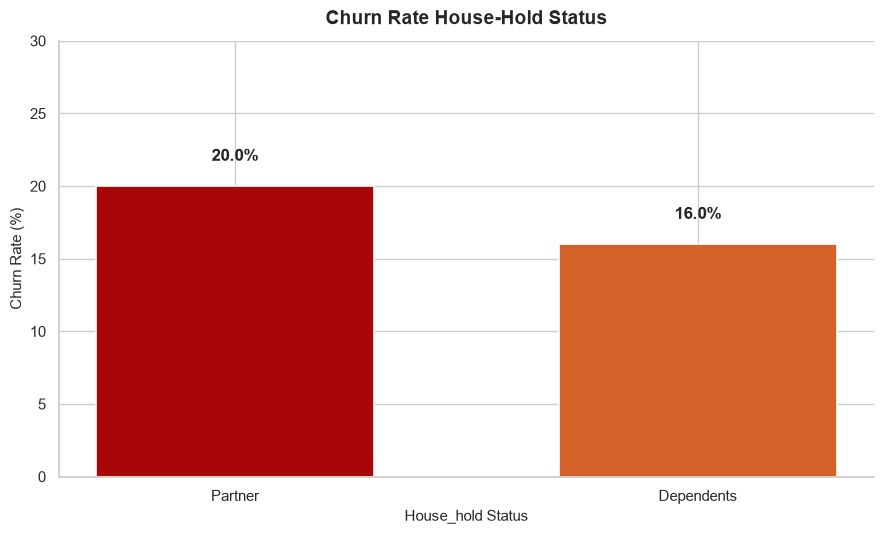

In [33]:
sql_file_path = Path("..") / "Queries" / "07_churn_rate_by_household_status.sql"

with open(sql_file_path) as f:
    query = f.read()
household_churn = pd.read_sql(query, engine)

display_result = household_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = household_churn["household_status"]
rates = household_churn["churn_rate"]

colors = ["#a90707", "#d46128", "#f3832d", "#dda927"]

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate House-Hold Status", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("House_hold Status", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 30)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by House-Hold Status")
plt.show()

**Conclusion:** Household status don't affect the churn rate as much as the other factors

### 8. Effect of Customer's Age on Churn Rate

,customer_age_status,total_customers,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Senior Citizen,1142,476,41.7%,91154.85,38419.60
1,Others,5890,1393,23.7%,364506.15,100711.25


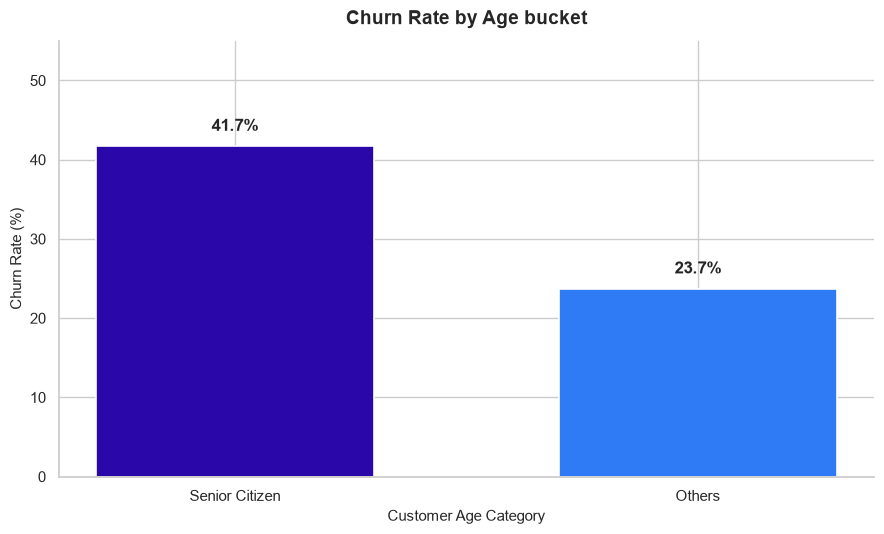

In [34]:
sql_file_path = Path("..") / "Queries" / "08_churn_rate_by_age_status.sql"

with open(sql_file_path) as f:
    query = f.read()
age_churn = pd.read_sql(query, engine)

display_result = age_churn.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5.5))

categories = age_churn["customer_age_status"]
rates = age_churn["churn_rate"]

colors = ["#2a07a9", "#2f7bf5", "#2d6cf3"] 

bars = plt.bar(categories, rates, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Churn Rate by Age bucket", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Customer Age Category", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0, 55)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Churn Rate by Age Bucket")
plt.show()

**Conclusion:** Senior citizens tend to churn more than other customers

### 9. High risk Profiles

In [35]:
sql_file_path = Path("..") / "Queries" / "09_High_risk_profiles.sql"

with open(sql_file_path) as f:
    query = f.read()
high_risk_profile = pd.read_sql(query, engine)

display_result = high_risk_profile.copy()

display_result['churn_rate'] = (
    display_result['churn_rate'].astype(str) + '%'
)

display(display_result)

,high_risk_profiles,churned_customers,churn_rate
0,916,643,70.2%


**Conclusion:** There are **916 high risk profiles** out of which 643 customers are already churned. Thus **273 customers have a high potential to churn**

### 10. Monthlty Revenue at Risk due to high risk profiles

In [36]:
sql_file_path = Path("..") / "Queries" / "10_Monthly_revenue_at_risk.sql"

with open(sql_file_path) as f:
    query = f.read()
monthly_revenue_at_risk = pd.read_sql(query, engine)
display(monthly_revenue_at_risk)


,churned_high_risk_customers,monthly_revenue_at_risk,average_monthly_revenue_at_risk
0,643,53178.3,82.7


**Conclusion:** The average monthly revenue at risk is **82.7** for each churned customers, so the potential monthly revenue at risk becomes 75753.2 which is a **42% jump** 

## 4. High-Risk Customer Profile

A high-risk customer profile is analyzed to determine whether a specific group of customers represents a disproportionately high level of churn and monthly revenue risk.
The high-risk customer segment is compared with all other customers based on the following metrics:

- **Customer Contract type**
- **Customer Tenure Period**
- **Customer Internet Service**

The rest parameters are not taken because it will cause a problem of overfitting
The analysis compares the high-risk segment with the rest of the customer base to assess the business impact and importance of prioritizing this group for customer retention efforts.

In [37]:
no_of_high_risk_customers = high_risk_profile["high_risk_profiles"].iloc[0]
other_customers = total_customers - no_of_high_risk_customers

no_of_churned_hrp_customers = high_risk_profile["churned_customers"].iloc[0]
no_of_other_churned_customers = churned_customers - no_of_churned_hrp_customers

monthly_revenue_at_risk_hrp = monthly_revenue_at_risk["monthly_revenue_at_risk"].iloc[0]
monthly_revenue_at_risk_other = total_monthly_revenue_loss - monthly_revenue_at_risk_hrp


data = {
    "Customer Segments": [
        "High Risk Customers",
        "Other Customers",
    ],

    "Customers": [
        no_of_high_risk_customers,
        other_customers
    ],

    "Customer Share":[
        round((no_of_high_risk_customers/total_customers)*100, 2),
        round((other_customers/total_customers)*100,2)
    ],

    "Churned Customer":[
        no_of_churned_hrp_customers,
        no_of_other_churned_customers
    ],

    "Churn Rate":[
        round((no_of_churned_hrp_customers/no_of_high_risk_customers)*100,1),
        round((no_of_other_churned_customers/other_customers)*100,1),
    ],

    "Monthly Revenue at Risk": [
    round(monthly_revenue_at_risk_hrp, 2),
    round(monthly_revenue_at_risk_other, 2)
],

"Revenue Risk Share": [
    round((monthly_revenue_at_risk_hrp / total_monthly_revenue_loss) * 100,1),
    round((monthly_revenue_at_risk_other / total_monthly_revenue_loss) * 100,1)
]
    
}
hrp_df = pd.DataFrame(data)

hrp_df


,Customer Segments,Customers,Customer Share,Churned Customer,Churn Rate,Monthly Revenue at Risk,Revenue Risk Share
0,High Risk Customers,916,13.01,643,70.2,53178.30,38.2
1,Other Customers,6127,86.99,1226,20.0,85952.55,61.8


**Conclusion:**
- The high-risk customer segment represents only **13.01% of the total customer base**, but accounts for a disproportionately high **churn rate of 70.2%**, compared with **20.0%** for other customers.

- This indicates that customers in the high-risk segment are significantly more likely to churn. Despite representing a relatively small share of customers, this segment contributes **38.2% of the total monthly revenue at risk**.

- The results suggest that identifying and targeting high-risk customers should be a priority for customer retention efforts, as reducing churn within this segment could help protect a significant portion of at-risk monthly revenue.

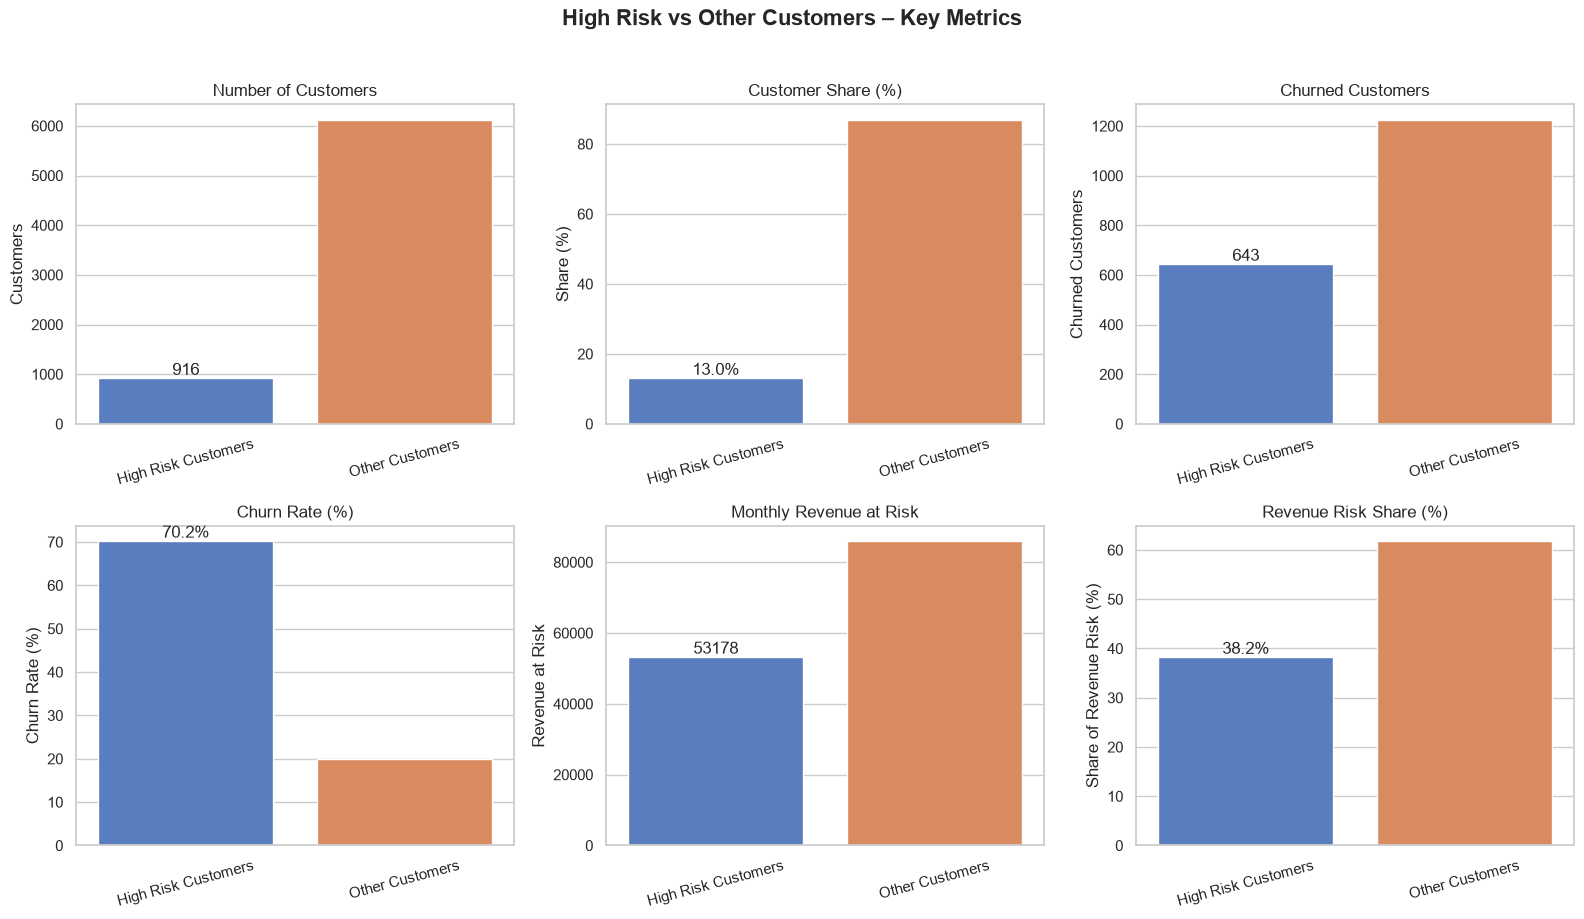

In [38]:
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("High Risk vs Other Customers – Key Metrics", fontsize=16, fontweight="bold", y=1.02)

colors = ["#2a07a9", "#a90707"]

sns.barplot(data=hrp_df, x="Customer Segments", y="Customers", ax=axes[0, 0], hue="Customer Segments", legend=False)
axes[0, 0].set_title("Number of Customers")
axes[0, 0].set_ylabel("Customers")
axes[0, 0].bar_label(axes[0, 0].containers[0], fmt="%.0f")


sns.barplot(data=hrp_df, x="Customer Segments", y="Customer Share", ax=axes[0, 1], hue="Customer Segments", legend=False)
axes[0, 1].set_title("Customer Share (%)")
axes[0, 1].set_ylabel("Share (%)")
axes[0, 1].bar_label(axes[0, 1].containers[0], fmt="%.1f%%")


sns.barplot(data=hrp_df, x="Customer Segments", y="Churned Customer", ax=axes[0, 2], hue="Customer Segments", legend=False)
axes[0, 2].set_title("Churned Customers")
axes[0, 2].set_ylabel("Churned Customers")
axes[0, 2].bar_label(axes[0, 2].containers[0], fmt="%.0f")


sns.barplot(data=hrp_df, x="Customer Segments", y="Churn Rate", ax=axes[1, 0], hue="Customer Segments", legend=False)
axes[1, 0].set_title("Churn Rate (%)")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].bar_label(axes[1, 0].containers[0], fmt="%.1f%%")


sns.barplot(data=hrp_df, x="Customer Segments", y="Monthly Revenue at Risk", ax=axes[1, 1], hue="Customer Segments", legend=False)
axes[1, 1].set_title("Monthly Revenue at Risk")
axes[1, 1].set_ylabel("Revenue at Risk")
axes[1, 1].bar_label(axes[1, 1].containers[0], fmt="%.0f")

sns.barplot(data=hrp_df, x="Customer Segments", y="Revenue Risk Share", ax=axes[1, 2], hue="Customer Segments", legend=False)
axes[1, 2].set_title("Revenue Risk Share (%)")
axes[1, 2].set_ylabel("Share of Revenue Risk (%)")
axes[1, 2].bar_label(axes[1, 2].containers[0], fmt="%.1f%%")


for ax in axes.flat:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("High Risk vs Other Customers – Key Metrics")
plt.show()

## 5. Key Findings:-

- Customers with a short tenure tend to churn more than the long-term customers. This can be because the frist 3-9 months is the time period where the customer decides the service worth keeping. The customers maybe facing some installation issues, charges higher than expected.
- Customers have a high churn rate when they selected the streaming services and on the other side important services like tech-support, online-security have a low churn rate. Maybe the customers are not enjoying the streaming content and it needs some improvement
- Customers who pays which electronic checks tends to churn more than customers with mailed check, credit cards, bank transaction. the reason for this can be because the eletronic checks are manual, there is a small chance of missed/late payments, service interruptions etc while the other payment meathods are auto matic, they remove monthlyeffort of customers
- Customers who get discount or pay more than regular churns less because they have genrally nicer experience because of the discounts or pay for add-ons which improve the user experience significantly
- Customers which are senior citizen churns more due to the  barriers like interface design, techinical complexity and their old age